In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

# Read dataset from GitHub
url = "https://raw.githubusercontent.com/majidramzi/correlation-regression-analysis/refs/heads/main/CCPP_data.csv"
df = pd.read_csv(url)


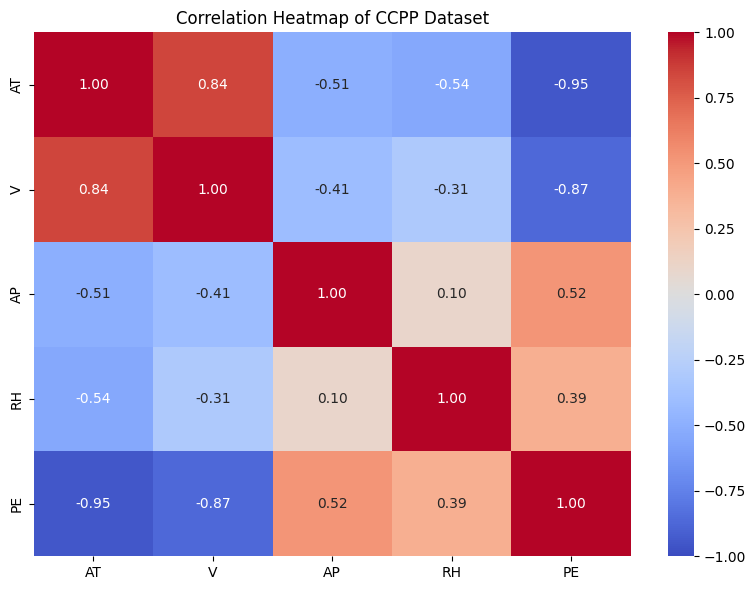

In [3]:
# 1. Correlation Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1)
plt.title('Correlation Heatmap of CCPP Dataset')
plt.tight_layout()
plt.show()



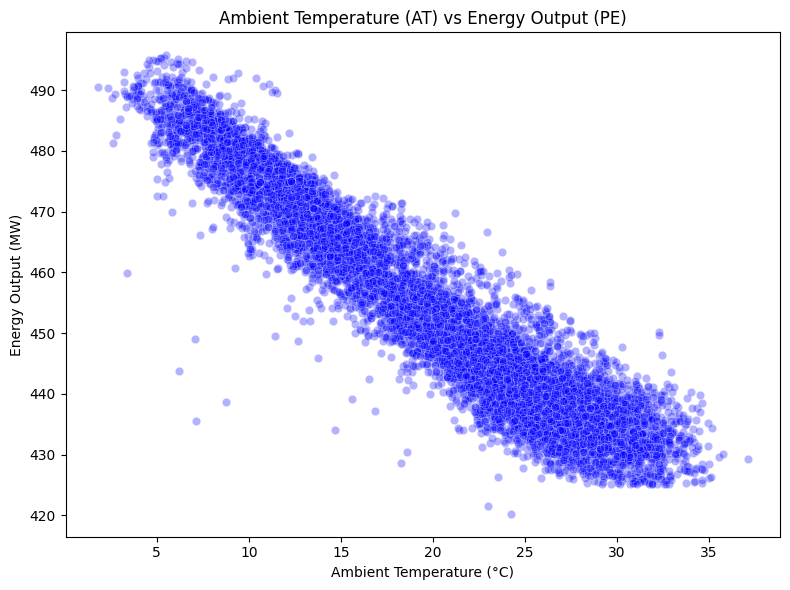

In [4]:
# 2. Scatter plot: Ambient Temperature vs Energy Output
plt.figure(figsize=(8, 6))
sns.scatterplot(x=df['AT'], y=df['PE'], alpha=0.3, color='blue')
plt.title('Ambient Temperature (AT) vs Energy Output (PE)')
plt.xlabel('Ambient Temperature (°C)')
plt.ylabel('Energy Output (MW)')
plt.tight_layout()
plt.show()



In [5]:
# 3. Multiple Linear Regression Model
X = df.drop('PE', axis=1)
y = df['PE']

model = LinearRegression()
model.fit(X, y)
y_pred = model.predict(X)
r2 = r2_score(y, y_pred)
print(f"R-squared (R2) Score: {r2:.4f}")



R-squared (R2) Score: 0.9287


/tmp/ipykernel_2997/3651642064.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


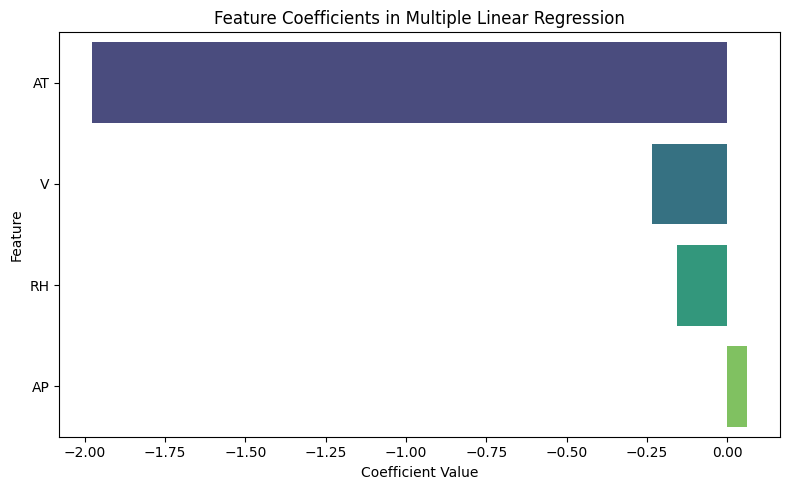

In [6]:
# 4. Feature Coefficients Visualization
coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values(by='Coefficient', ascending=True)

plt.figure(figsize=(8, 5))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title('Feature Coefficients in Multiple Linear Regression')
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

The Combined Cycle Power Plant (CCPP) dataset provides a realistic look at thermodynamic variables in energy engineering. The correlation heatmap reveals a very strong negative correlation between Ambient Temperature (AT) and the electrical energy output (PE). Exhaust Vacuum (V) also shows a significant negative relationship with power generation. This aligns perfectly with thermodynamic principles: as environmental temperature and exhaust vacuum increase, the plant's overall efficiency drops, leading to lower net energy production.

The scatter plot mapping AT against PE visually confirms this strict linear dependency. The data points form a tight, downward-sloping band, proving that ambient temperature is the most dominant predictor of performance.

When applying the multiple linear regression model, the feature coefficient visualization isolates the impact of each independent variable. The coefficient for temperature (AT) holds the most prominent negative value. This confirms that even when accounting for ambient pressure (AP) and relative humidity (RH), a rise in ambient temperature causes the steepest penalty to the power plant's hourly energy output.